# FBS Detection Model Testing

This notebook loads saved models (LSTM, GRU, CNN) and tests them on the dataset from csv_output folder.

In [19]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import json
import os
import glob
import time
import gc
import tracemalloc
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Model Definitions

Define all model architectures (must match the training definitions)

In [20]:
# ======================================================
# LSTM Model
# ======================================================
class LSTMSeqClassifier(nn.Module):
    def __init__(self, feature_dim, hidden_dim=128, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3,
            bidirectional=False
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        last_hidden = hn[-1]
        return self.fc(last_hidden)


# ======================================================
# GRU Model
# ======================================================
class GRUSeqClassifier(nn.Module):
    def __init__(self, feature_dim, hidden_dim=128, num_layers=2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3,
            bidirectional=False
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        out, hn = self.gru(x)
        last_hidden = hn[-1]
        return self.fc(last_hidden)


# ======================================================
# CNN Model
# ======================================================
class CNN1DSeqClassifier(nn.Module):
    def __init__(self, input_channels, seq_length):
        super().__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv1d(input_channels, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(0.2),
            
            nn.Conv1d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(0.2),
            
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
        )
        
        conv_output_size = seq_length // 4
        flattened_size = 64 * conv_output_size
        
        self.fc_layers = nn.Sequential(
            nn.Linear(flattened_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

print("Model classes defined.")

Model classes defined.


## 2. Configuration

In [21]:
# ======================================================
# Configuration
# ======================================================
WINDOW_SIZE = 20
FEATURE_DIM = 1408  # Will be verified when loading data

# Paths
DATASET_PATH = "../dataset/csv_output/"

# Model paths - Update these based on available models
MODELS = {
    # "lstm": {
    #     "model_path": "fbsdetector_lstm.pth",
    #     "scaling_path": "scaling_parameters.json",
    #     "class": LSTMSeqClassifier,
    #     "type": "rnn"  # rnn or cnn
    # },
    "gru": {
        "model_path": "fbsdetector_gru.pth",
        "scaling_path": "scaling_parameters_gru.json",
        "class": GRUSeqClassifier,
        "type": "rnn"
    },
    "cnn": {
        "model_path": "fbsdetector_cnn.pth",
        "scaling_path": "scaling_parameters_cnn.json",
        "class": CNN1DSeqClassifier,
        "type": "cnn"
    }
}

# Check which models are available
available_models = {}
for name, config in MODELS.items():
    if os.path.exists(config["model_path"]) and os.path.exists(config["scaling_path"]):
        available_models[name] = config
        print(f"Found model: {name}")
    else:
        print(f"Model not found: {name} (missing {config['model_path']} or {config['scaling_path']})")

print(f"\nAvailable models: {list(available_models.keys())}")

Found model: gru
Found model: cnn

Available models: ['gru', 'cnn']


## 3. Load Test Data from csv_output

In [22]:
# ======================================================
# Load all datasets from csv_output folder
# ======================================================

def load_datasets_from_folder(base_path):
    """Load all essential.csv files from subfolders"""
    all_data = []
    dataset_info = []
    
    # Get all subfolders
    subfolders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
    
    for folder in sorted(subfolders):
        folder_path = os.path.join(base_path, folder)
        
        # Find essential.csv file
        csv_files = glob.glob(os.path.join(folder_path, "*_essential.csv"))
        
        if csv_files:
            csv_path = csv_files[0]
            try:
                df = pd.read_csv(csv_path)
                
                # Determine if it's attack or normal based on folder name
                folder_lower = folder.lower()
                if "normal" in folder_lower:
                    label = 0
                    data_type = "normal"
                else:
                    label = 1
                    data_type = "attack"
                
                df["label"] = label
                df["source"] = folder
                
                all_data.append(df)
                dataset_info.append({
                    "folder": folder,
                    "type": data_type,
                    "samples": len(df)
                })
                
                print(f"Loaded: {folder} ({data_type}) - {len(df)} samples")
                
            except Exception as e:
                print(f"Error loading {csv_path}: {e}")
    
    return all_data, dataset_info


# Load data
print("Loading datasets...\n")
all_data, dataset_info = load_datasets_from_folder(DATASET_PATH)

# Combine all data
if all_data:
    combined_df = pd.concat(all_data, ignore_index=True)
    print(f"\n" + "="*50)
    print(f"Total samples loaded: {len(combined_df)}")
    print(f"Normal samples: {len(combined_df[combined_df['label'] == 0])}")
    print(f"Attack samples: {len(combined_df[combined_df['label'] == 1])}")
    print("="*50)
else:
    print("No data loaded!")

Loading datasets...

Loaded: attach_reject2_20251211_171715 (attack) - 278 samples
Loaded: attach_reject_20251211_171644 (attack) - 161 samples
Loaded: auth_relay_synch_failure_20251211_171608 (attack) - 232 samples
Loaded: authentication_failure_20251211_171624 (attack) - 130 samples
Loaded: capability_hijacking_20251211_171719 (attack) - 163 samples
Loaded: detach_downgrade2_20251211_171641 (attack) - 317 samples
Loaded: detach_downgrade3_20251211_171700 (attack) - 278 samples
Loaded: detach_downgrade_20251211_171622 (attack) - 267 samples
Loaded: downgrade_tau_attack_20251211_171602 (attack) - 561 samples
Loaded: emm_information_20251211_171649 (attack) - 374 samples
Loaded: energy_depletion_20251211_171619 (attack) - 429 samples
Loaded: handover_hijacking_20251211_171721 (attack) - 492 samples
Loaded: imei_catching_20251211_171723 (attack) - 285 samples
Loaded: imsi_catching_20251211_171638 (attack) - 26 samples
Loaded: location_tracking_measurement_report_20251211_171717 (attack) 

In [23]:
# ======================================================
# Dataset Summary
# ======================================================
info_df = pd.DataFrame(dataset_info)
print("\nDataset Summary:")
print(info_df.to_string())

print(f"\nBy Type:")
print(info_df.groupby('type')['samples'].agg(['count', 'sum']))


Dataset Summary:
                                                  folder    type  samples
0                         attach_reject2_20251211_171715  attack      278
1                          attach_reject_20251211_171644  attack      161
2               auth_relay_synch_failure_20251211_171608  attack      232
3                 authentication_failure_20251211_171624  attack      130
4                   capability_hijacking_20251211_171719  attack      163
5                      detach_downgrade2_20251211_171641  attack      317
6                      detach_downgrade3_20251211_171700  attack      278
7                       detach_downgrade_20251211_171622  attack      267
8                   downgrade_tau_attack_20251211_171602  attack      561
9                        emm_information_20251211_171649  attack      374
10                      energy_depletion_20251211_171619  attack      429
11                    handover_hijacking_20251211_171721  attack      492
12                  

## 4. Preprocess Data

In [24]:
# ======================================================
# Preprocessing Functions
# ======================================================

def create_sliding_windows(X, y, window_size=20):
    """Create sliding window sequences"""
    X_seq = []
    y_seq = []

    for i in range(len(X) - window_size):
        X_seq.append(X[i : i + window_size])
        y_seq.append(y[i + window_size])

    return np.array(X_seq), np.array(y_seq)


def scale_data(X, feature_min, feature_max):
    """Scale data using saved min/max parameters"""
    feature_min = np.array(feature_min)
    feature_max = np.array(feature_max)
    
    # Avoid division by zero
    range_vals = feature_max - feature_min
    range_vals[range_vals == 0] = 1
    
    X_scaled = (X - feature_min) / range_vals
    return np.clip(X_scaled, 0, 1)  # Clip to [0, 1]


# Remove non-feature columns
cols_to_remove = ["label", "source", "timestamp", "message_index", "packet_type", "direction", "info"]
feature_cols = [col for col in combined_df.columns if col not in cols_to_remove]

X = combined_df[feature_cols].values
y = combined_df["label"].values

print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Number of features: {len(feature_cols)}")

# Update FEATURE_DIM
FEATURE_DIM = X.shape[1]
print(f"\nUpdated FEATURE_DIM: {FEATURE_DIM}")

Feature matrix shape: (19957, 1408)
Labels shape: (19957,)
Number of features: 1408

Updated FEATURE_DIM: 1408


In [25]:
# ======================================================
# Create Sliding Windows
# ======================================================
X_seq, y_seq = create_sliding_windows(X, y, window_size=WINDOW_SIZE)

print(f"Sequence shape: {X_seq.shape}")
print(f"Labels shape: {y_seq.shape}")
print(f"\nLabel distribution:")
unique, counts = np.unique(y_seq, return_counts=True)
for u, c in zip(unique, counts):
    label_name = "Normal" if u == 0 else "Attack"
    print(f"  {label_name}: {c} ({c/len(y_seq)*100:.1f}%)")

Sequence shape: (19937, 20, 1408)
Labels shape: (19937,)

Label distribution:
  Normal: 514 (2.6%)
  Attack: 19423 (97.4%)


## 5. Load and Test Models

In [26]:
# ======================================================
# Testing Function
# ======================================================

def test_model(model_name, model_config, X_seq, y_seq, device):
    """Load a model and test it on the data"""
    print(f"\n{'='*60}")
    print(f"Testing {model_name.upper()} Model")
    print(f"{'='*60}")
    
    # 1. Load scaling parameters
    with open(model_config["scaling_path"], "r") as f:
        scaling_data = json.load(f)
    
    feature_min = scaling_data["feature_min"]
    feature_max = scaling_data["feature_max"]
    
    # 2. Scale data
    X_2d = X_seq.reshape(-1, X_seq.shape[2])
    X_2d_scaled = scale_data(X_2d, feature_min, feature_max)
    X_scaled = X_2d_scaled.reshape(X_seq.shape)
    
    print(f"Scaled data shape: {X_scaled.shape}")
    
    # 3. Initialize model
    if model_config["type"] == "cnn":
        model = model_config["class"](input_channels=FEATURE_DIM, seq_length=WINDOW_SIZE)
    else:  # rnn (LSTM, GRU)
        model = model_config["class"](feature_dim=FEATURE_DIM)
    
    # 4. Load weights
    model.load_state_dict(torch.load(model_config["model_path"], map_location=device))
    model.to(device)
    model.eval()
    
    print(f"Model loaded from: {model_config['model_path']}")
    
    # 5. Prepare data for model
    if model_config["type"] == "cnn":
        # CNN expects (batch, channels, seq_length)
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32).permute(0, 2, 1)
    else:
        # RNN expects (batch, seq_length, features)
        X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    
    # 6. Run predictions in batches
    batch_size = 64
    y_pred = []
    y_prob = []
    
    with torch.no_grad():
        for i in range(0, len(X_tensor), batch_size):
            batch = X_tensor[i:i+batch_size].to(device)
            logits = model(batch)
            proba = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            
            y_pred.extend(pred)
            y_prob.extend(proba)
    
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)
    
    # 7. Calculate metrics
    acc = accuracy_score(y_seq, y_pred)
    prec = precision_score(y_seq, y_pred, zero_division=0)
    rec = recall_score(y_seq, y_pred, zero_division=0)
    f1 = f1_score(y_seq, y_pred, zero_division=0)
    
    cm = confusion_matrix(y_seq, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    try:
        auc = roc_auc_score(y_seq, y_prob)
    except:
        auc = 0.0
    
    # 8. Print results
    print(f"\n--- Results ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC:       {auc:.4f}")
    print(f"FPR:       {fpr:.4f}")
    
    print(f"\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")
    
    print(f"\nClassification Report:")
    print(classification_report(y_seq, y_pred, target_names=["Normal", "Attack"]))
    
    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
        "fpr": fpr,
        "confusion_matrix": cm,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

In [27]:
# ======================================================
# Run Tests on All Available Models
# ======================================================
results = {}

for model_name, model_config in available_models.items():
    try:
        result = test_model(model_name, model_config, X_seq, y_seq, device)
        results[model_name] = result
    except Exception as e:
        print(f"\nError testing {model_name}: {e}")
        import traceback
        traceback.print_exc()


Testing GRU Model
Scaled data shape: (19937, 20, 1408)
Model loaded from: fbsdetector_gru.pth

--- Results ---
Accuracy:  0.9986
Precision: 0.9995
Recall:    0.9991
F1 Score:  0.9993
AUC:       0.9990
FPR:       0.0195

Confusion Matrix:
  TN: 504  FP: 10
  FN: 18  TP: 19405

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.97       514
      Attack       1.00      1.00      1.00     19423

    accuracy                           1.00     19937
   macro avg       0.98      0.99      0.99     19937
weighted avg       1.00      1.00      1.00     19937


Testing CNN Model
Scaled data shape: (19937, 20, 1408)
Model loaded from: fbsdetector_cnn.pth

--- Results ---
Accuracy:  0.9943
Precision: 0.9995
Recall:    0.9946
F1 Score:  0.9971
AUC:       0.9920
FPR:       0.0175

Confusion Matrix:
  TN: 505  FP: 9
  FN: 105  TP: 19318

Classification Report:
              precision    recall  f1-score   support

      Normal    

## 6. Visualization

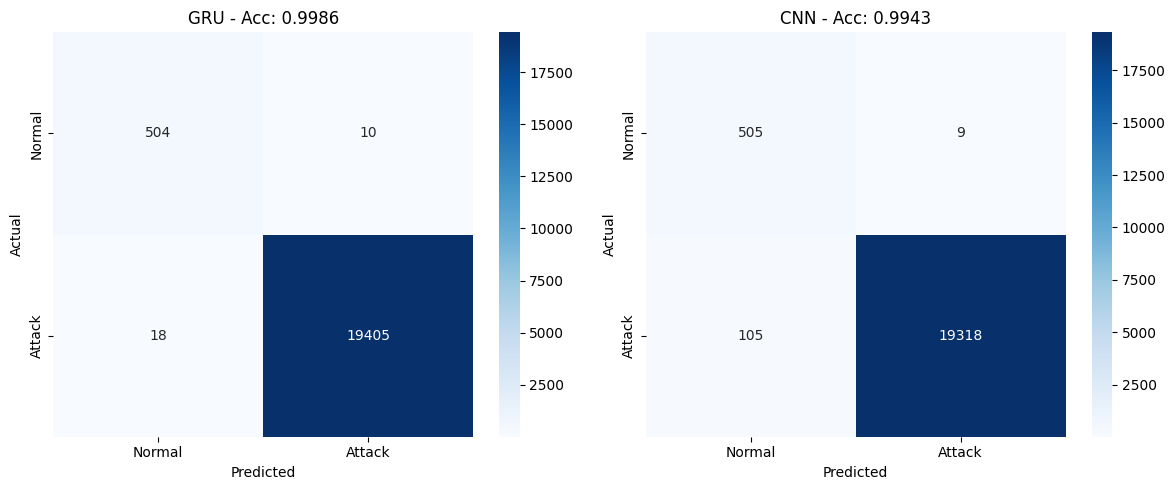

In [28]:
# ======================================================
# Plot Confusion Matrices
# ======================================================
n_models = len(results)
if n_models > 0:
    fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))
    
    if n_models == 1:
        axes = [axes]
    
    for ax, (model_name, result) in zip(axes, results.items()):
        cm = result["confusion_matrix"]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=["Normal", "Attack"],
                    yticklabels=["Normal", "Attack"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(f"{model_name.upper()} - Acc: {result['accuracy']:.4f}")
    
    plt.tight_layout()
    plt.show()
else:
    print("No results to plot.")

In [29]:
# ======================================================
# Model Comparison Table
# ======================================================
if results:
    comparison_data = []
    for model_name, result in results.items():
        comparison_data.append({
            "Model": model_name.upper(),
            "Accuracy": f"{result['accuracy']:.4f}",
            "Precision": f"{result['precision']:.4f}",
            "Recall": f"{result['recall']:.4f}",
            "F1 Score": f"{result['f1']:.4f}",
            "AUC": f"{result['auc']:.4f}",
            "FPR": f"{result['fpr']:.4f}"
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    print("\n" + "="*80)
    print("MODEL COMPARISON")
    print("="*80)
    print(comparison_df.to_string(index=False))
    print("="*80)


MODEL COMPARISON
Model Accuracy Precision Recall F1 Score    AUC    FPR
  GRU   0.9986    0.9995 0.9991   0.9993 0.9990 0.0195
  CNN   0.9943    0.9995 0.9946   0.9971 0.9920 0.0175


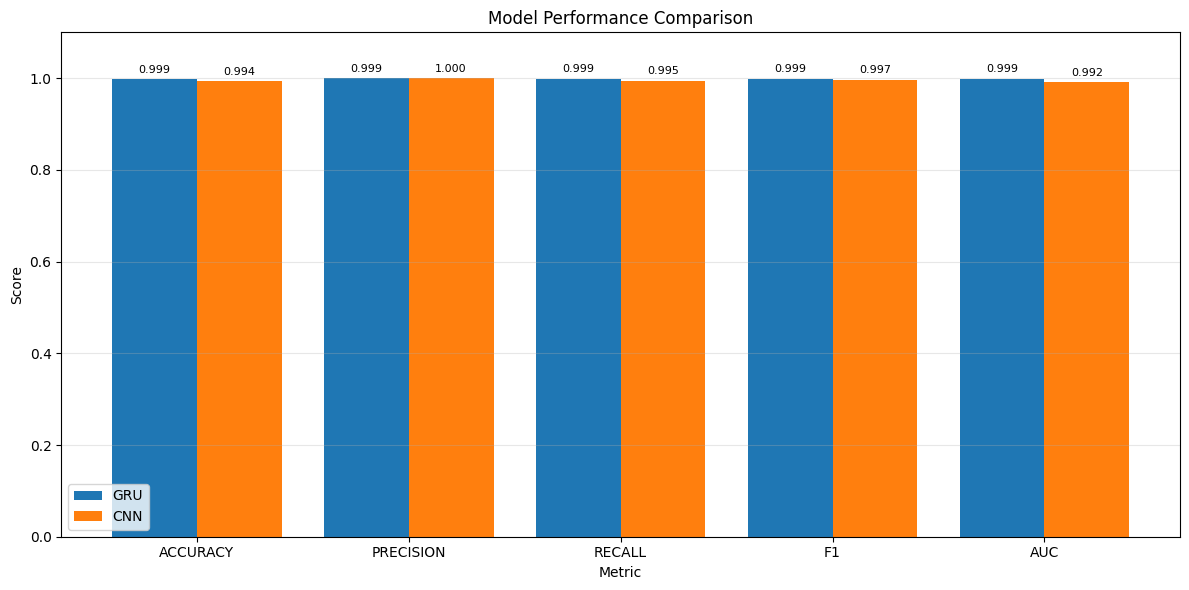

In [30]:
# ======================================================
# Bar Chart Comparison
# ======================================================
if results:
    metrics = ["accuracy", "precision", "recall", "f1", "auc"]
    model_names = list(results.keys())
    
    x = np.arange(len(metrics))
    width = 0.8 / len(model_names)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for i, model_name in enumerate(model_names):
        values = [results[model_name][m] for m in metrics]
        bars = ax.bar(x + i*width, values, width, label=model_name.upper())
        
        # Add value labels on bars
        for bar, val in zip(bars, values):
            ax.annotate(f'{val:.3f}',
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)
    
    ax.set_xlabel('Metric')
    ax.set_ylabel('Score')
    ax.set_title('Model Performance Comparison')
    ax.set_xticks(x + width * (len(model_names) - 1) / 2)
    ax.set_xticklabels([m.upper() for m in metrics])
    ax.legend()
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 7. Per-Attack Type Analysis (Optional)

In [31]:
# ======================================================
# Test on Individual Attack Types
# ======================================================

def test_per_attack_type(model_name, model_config, base_path, device):
    """Test model on each attack type separately"""
    print(f"\n{'='*60}")
    print(f"Per-Attack Analysis: {model_name.upper()}")
    print(f"{'='*60}")
    
    # Load scaling parameters
    with open(model_config["scaling_path"], "r") as f:
        scaling_data = json.load(f)
    feature_min = scaling_data["feature_min"]
    feature_max = scaling_data["feature_max"]
    
    # Initialize model
    if model_config["type"] == "cnn":
        model = model_config["class"](input_channels=FEATURE_DIM, seq_length=WINDOW_SIZE)
    else:
        model = model_config["class"](feature_dim=FEATURE_DIM)
    
    model.load_state_dict(torch.load(model_config["model_path"], map_location=device))
    model.to(device)
    model.eval()
    
    # Test each folder
    attack_results = []
    subfolders = sorted([f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))])
    
    for folder in subfolders:
        folder_path = os.path.join(base_path, folder)
        csv_files = glob.glob(os.path.join(folder_path, "*_essential.csv"))
        
        if not csv_files:
            continue
            
        try:
            df = pd.read_csv(csv_files[0])
            
            # Determine label
            is_normal = "normal" in folder.lower()
            true_label = 0 if is_normal else 1
            
            # Get features
            cols_to_remove = ["label", "source", "timestamp", "message_index", "packet_type", "direction", "info"]
            feature_cols = [col for col in df.columns if col not in cols_to_remove]
            X = df[feature_cols].values
            y = np.full(len(X), true_label)
            
            if len(X) <= WINDOW_SIZE:
                continue
            
            # Create sequences
            X_seq, y_seq = create_sliding_windows(X, y, window_size=WINDOW_SIZE)
            
            # Scale
            X_2d = X_seq.reshape(-1, X_seq.shape[2])
            X_2d_scaled = scale_data(X_2d, feature_min, feature_max)
            X_scaled = X_2d_scaled.reshape(X_seq.shape)
            
            # Prepare tensor
            if model_config["type"] == "cnn":
                X_tensor = torch.tensor(X_scaled, dtype=torch.float32).permute(0, 2, 1)
            else:
                X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
            
            # Predict
            with torch.no_grad():
                X_tensor = X_tensor.to(device)
                logits = model(X_tensor)
                y_pred = torch.argmax(logits, dim=1).cpu().numpy()
            
            # Calculate accuracy
            correct = np.sum(y_pred == y_seq)
            total = len(y_seq)
            acc = correct / total
            
            attack_type = "Normal" if is_normal else folder.split("_20")[0]
            attack_results.append({
                "Attack Type": attack_type,
                "True Label": "Normal" if true_label == 0 else "Attack",
                "Samples": total,
                "Correct": correct,
                "Accuracy": f"{acc:.4f}",
                "Detection Rate": f"{np.mean(y_pred):.4f}"
            })
            
        except Exception as e:
            print(f"Error with {folder}: {e}")
    
    # Display results
    results_df = pd.DataFrame(attack_results)
    print("\n" + results_df.to_string(index=False))
    
    return results_df

# Run per-attack analysis for first available model
if available_models:
    first_model_name = list(available_models.keys())[0]
    per_attack_df = test_per_attack_type(
        first_model_name, 
        available_models[first_model_name], 
        DATASET_PATH, 
        device
    )


Per-Attack Analysis: GRU

                         Attack Type True Label  Samples  Correct Accuracy Detection Rate
                      attach_reject2     Attack      258      258   1.0000         1.0000
                       attach_reject     Attack      141      141   1.0000         1.0000
            auth_relay_synch_failure     Attack      212      212   1.0000         1.0000
              authentication_failure     Attack      110      110   1.0000         1.0000
                capability_hijacking     Attack      143      143   1.0000         1.0000
                   detach_downgrade2     Attack      297      297   1.0000         1.0000
                   detach_downgrade3     Attack      258      258   1.0000         1.0000
                    detach_downgrade     Attack      247      247   1.0000         1.0000
                downgrade_tau_attack     Attack      541      541   1.0000         1.0000
                     emm_information     Attack      354      354   1.000

## 8. Model Benchmark - Computation Overhead & Memory Usage

This section measures:
- **Inference Time (ms)**: Average time to process one sample
- **Model Size (MB)**: Memory footprint of model parameters
- **Peak Memory (MB)**: Maximum memory used during inference
- **Throughput (samples/sec)**: Processing speed at different batch sizes

In [32]:
# ======================================================
# Benchmark Functions for Computation Overhead & Memory Usage
# ======================================================

def get_model_size_mb(model):
    """Calculate model size in MB"""
    param_size = 0
    buffer_size = 0
    
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()
    
    size_mb = (param_size + buffer_size) / (1024 ** 2)
    return size_mb


def get_model_parameters(model):
    """Get total number of trainable parameters"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def measure_inference_time(model, input_tensor, device, num_runs=100, warmup_runs=10):
    """
    Measure average inference time in milliseconds.
    """
    model.eval()
    input_tensor = input_tensor.to(device)
    
    # Warmup runs
    with torch.no_grad():
        for _ in range(warmup_runs):
            _ = model(input_tensor)
    
    if device.type == 'cuda':
        torch.cuda.synchronize()
    
    # Measurement runs
    times = []
    with torch.no_grad():
        for _ in range(num_runs):
            start_time = time.perf_counter()
            _ = model(input_tensor)
            
            if device.type == 'cuda':
                torch.cuda.synchronize()
            
            end_time = time.perf_counter()
            times.append((end_time - start_time) * 1000)  # Convert to ms
    
    return {
        "avg_time_ms": np.mean(times),
        "std_time_ms": np.std(times),
        "min_time_ms": np.min(times),
        "max_time_ms": np.max(times)
    }


def measure_memory_usage(model, input_tensor, device):
    """
    Measure memory usage during inference.
    """
    model.eval()
    
    # Get model memory
    model_memory_mb = get_model_size_mb(model)
    
    # Measure CPU memory using tracemalloc
    gc.collect()
    tracemalloc.start()
    
    input_tensor = input_tensor.to(device)
    
    with torch.no_grad():
        _ = model(input_tensor)
    
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    
    cpu_memory_mb = peak / (1024 ** 2)
    
    # For CUDA, measure GPU memory
    gpu_memory_mb = 0
    if device.type == 'cuda':
        torch.cuda.reset_peak_memory_stats()
        
        with torch.no_grad():
            _ = model(input_tensor)
        
        gpu_memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
    
    return {
        "model_memory_mb": model_memory_mb,
        "peak_cpu_memory_mb": cpu_memory_mb,
        "peak_gpu_memory_mb": gpu_memory_mb
    }


def measure_throughput(model, input_shape, device, batch_sizes=[1, 8, 16, 32, 64], num_runs=50):
    """
    Measure throughput (samples/second) for different batch sizes.
    """
    model.eval()
    throughput_results = {}
    
    for batch_size in batch_sizes:
        test_input = torch.randn(batch_size, *input_shape[1:]).to(device)
        
        # Warmup
        with torch.no_grad():
            for _ in range(5):
                _ = model(test_input)
        
        if device.type == 'cuda':
            torch.cuda.synchronize()
        
        # Measure
        start_time = time.perf_counter()
        with torch.no_grad():
            for _ in range(num_runs):
                _ = model(test_input)
        
        if device.type == 'cuda':
            torch.cuda.synchronize()
        
        end_time = time.perf_counter()
        
        total_samples = batch_size * num_runs
        total_time = end_time - start_time
        samples_per_second = total_samples / total_time
        
        throughput_results[batch_size] = samples_per_second
    
    return throughput_results


def benchmark_model(model, model_name, input_tensor, device, num_inference_runs=100):
    """
    Complete benchmark of a model.
    """
    print(f"\n--- Benchmarking {model_name.upper()} ---")
    
    # Model info
    num_params = get_model_parameters(model)
    model_size = get_model_size_mb(model)
    
    print(f"Parameters: {num_params:,}")
    print(f"Model Size: {model_size:.4f} MB")
    
    # Inference time
    time_results = measure_inference_time(
        model, input_tensor, device, 
        num_runs=num_inference_runs, warmup_runs=10
    )
    print(f"Inference Time (single sample):")
    print(f"  Average: {time_results['avg_time_ms']:.4f} ms")
    print(f"  Std Dev: {time_results['std_time_ms']:.4f} ms")
    print(f"  Min: {time_results['min_time_ms']:.4f} ms")
    print(f"  Max: {time_results['max_time_ms']:.4f} ms")
    
    # Memory usage
    memory_results = measure_memory_usage(model, input_tensor, device)
    print(f"Memory Usage:")
    print(f"  Model Memory: {memory_results['model_memory_mb']:.4f} MB")
    print(f"  Peak CPU Memory: {memory_results['peak_cpu_memory_mb']:.4f} MB")
    if device.type == 'cuda':
        print(f"  Peak GPU Memory: {memory_results['peak_gpu_memory_mb']:.4f} MB")
    
    # Throughput
    input_shape = input_tensor.shape
    throughput_results = measure_throughput(
        model, input_shape, device, 
        batch_sizes=[1, 8, 16, 32, 64], num_runs=50
    )
    print(f"Throughput (samples/second):")
    for batch_size, throughput in throughput_results.items():
        print(f"  Batch {batch_size}: {throughput:.2f} samples/sec")
    
    return {
        "model_name": model_name,
        "num_parameters": num_params,
        "model_size_mb": model_size,
        "inference_time_ms": time_results["avg_time_ms"],
        "inference_std_ms": time_results["std_time_ms"],
        "inference_min_ms": time_results["min_time_ms"],
        "inference_max_ms": time_results["max_time_ms"],
        "model_memory_mb": memory_results["model_memory_mb"],
        "peak_cpu_memory_mb": memory_results["peak_cpu_memory_mb"],
        "peak_gpu_memory_mb": memory_results["peak_gpu_memory_mb"],
        "throughput": throughput_results
    }

print("Benchmark functions defined.")

Benchmark functions defined.


In [33]:
# ======================================================
# Run Benchmarks on All Available Models
# ======================================================
benchmark_results = {}

for model_name, model_config in available_models.items():
    try:
        print(f"\n{'='*60}")
        print(f"Benchmarking {model_name.upper()} Model")
        print(f"{'='*60}")
        
        # Initialize model
        if model_config["type"] == "cnn":
            model = model_config["class"](input_channels=FEATURE_DIM, seq_length=WINDOW_SIZE)
            # CNN expects (batch, channels, seq_length)
            sample_input = torch.randn(1, FEATURE_DIM, WINDOW_SIZE)
        else:  # rnn (LSTM, GRU)
            model = model_config["class"](feature_dim=FEATURE_DIM)
            # RNN expects (batch, seq_length, features)
            sample_input = torch.randn(1, WINDOW_SIZE, FEATURE_DIM)
        
        # Load weights
        model.load_state_dict(torch.load(model_config["model_path"], map_location=device, weights_only=True))
        model.to(device)
        model.eval()
        
        # Run benchmark
        benchmark = benchmark_model(
            model=model,
            model_name=model_name,
            input_tensor=sample_input,
            device=device,
            num_inference_runs=100
        )
        
        benchmark_results[model_name] = benchmark
        
    except Exception as e:
        print(f"\nError benchmarking {model_name}: {e}")
        import traceback
        traceback.print_exc()

print(f"\n{'='*60}")
print(f"Benchmarking complete for {len(benchmark_results)} models")
print(f"{'='*60}")


Benchmarking GRU Model

--- Benchmarking GRU ---
Parameters: 698,050
Model Size: 2.6628 MB
Inference Time (single sample):
  Average: 0.4634 ms
  Std Dev: 0.1301 ms
  Min: 0.4281 ms
  Max: 1.4395 ms
Memory Usage:
  Model Memory: 2.6628 MB
  Peak CPU Memory: 0.0036 MB
Throughput (samples/second):
  Batch 1: 2250.06 samples/sec
  Batch 8: 7724.51 samples/sec
  Batch 16: 11133.89 samples/sec
  Batch 32: 12423.31 samples/sec
  Batch 64: 14737.81 samples/sec

Benchmarking CNN Model

--- Benchmarking CNN ---
Parameters: 1,255,042
Model Size: 4.7910 MB
Inference Time (single sample):
  Average: 0.2967 ms
  Std Dev: 0.0186 ms
  Min: 0.2676 ms
  Max: 0.4075 ms
Memory Usage:
  Model Memory: 4.7910 MB
  Peak CPU Memory: 0.0039 MB
Throughput (samples/second):
  Batch 1: 3221.06 samples/sec
  Batch 8: 8867.60 samples/sec
  Batch 16: 361.94 samples/sec
  Batch 32: 401.45 samples/sec
  Batch 64: 430.72 samples/sec

Benchmarking complete for 2 models


In [34]:
# ======================================================
# Benchmark Comparison Table
# ======================================================
if benchmark_results:
    benchmark_data = []
    for model_name, benchmark in benchmark_results.items():
        benchmark_data.append({
            "Model": model_name.upper(),
            "Parameters": f"{benchmark['num_parameters']:,}",
            "Model Size (MB)": f"{benchmark['model_size_mb']:.4f}",
            "Inference Time (ms)": f"{benchmark['inference_time_ms']:.4f}",
            "Inference Std (ms)": f"{benchmark['inference_std_ms']:.4f}",
            "Peak CPU Mem (MB)": f"{benchmark['peak_cpu_memory_mb']:.4f}",
            "Throughput @1": f"{benchmark['throughput'][1]:.1f}",
            "Throughput @64": f"{benchmark['throughput'][64]:.1f}"
        })
    
    benchmark_df = pd.DataFrame(benchmark_data)
    print("\n" + "="*100)
    print("BENCHMARK COMPARISON")
    print("="*100)
    print(benchmark_df.to_string(index=False))
    print("="*100)


BENCHMARK COMPARISON
Model Parameters Model Size (MB) Inference Time (ms) Inference Std (ms) Peak CPU Mem (MB) Throughput @1 Throughput @64
  GRU    698,050          2.6628              0.4634             0.1301            0.0036        2250.1        14737.8
  CNN  1,255,042          4.7910              0.2967             0.0186            0.0039        3221.1          430.7


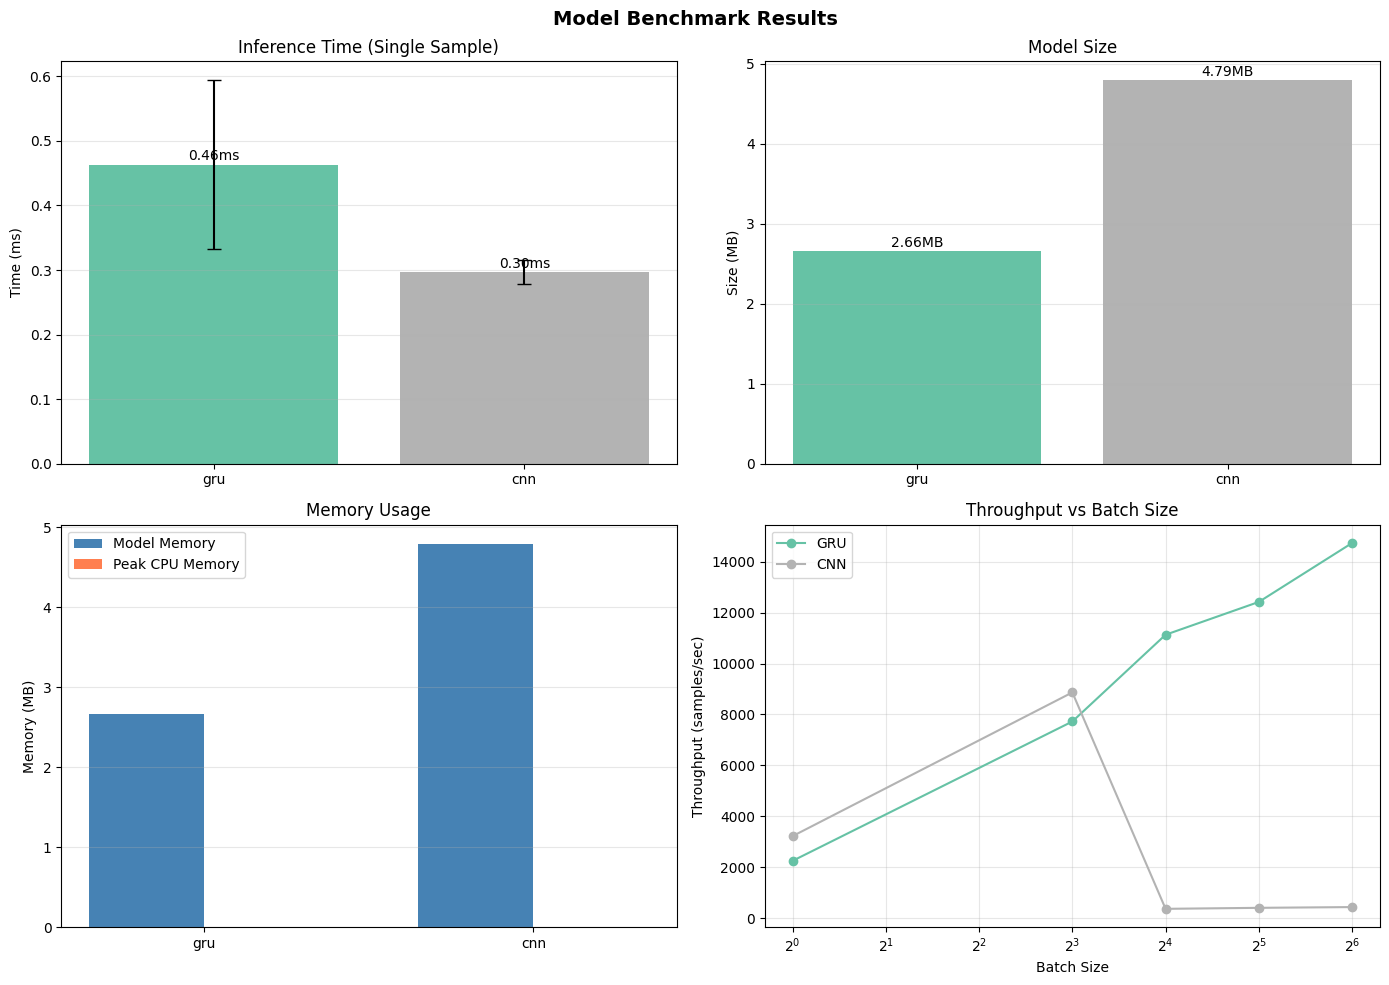

In [35]:
# ======================================================
# Benchmark Visualization
# ======================================================
if benchmark_results:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    model_names = list(benchmark_results.keys())
    colors = plt.cm.Set2(np.linspace(0, 1, len(model_names)))
    
    # 1. Inference Time Comparison
    ax1 = axes[0, 0]
    times = [benchmark_results[m]["inference_time_ms"] for m in model_names]
    stds = [benchmark_results[m]["inference_std_ms"] for m in model_names]
    bars = ax1.bar(model_names, times, yerr=stds, capsize=5, color=colors)
    ax1.set_ylabel("Time (ms)")
    ax1.set_title("Inference Time (Single Sample)")
    for bar, val in zip(bars, times):
        ax1.annotate(f'{val:.2f}ms', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)
    ax1.grid(axis='y', alpha=0.3)
    
    # 2. Model Size Comparison
    ax2 = axes[0, 1]
    sizes = [benchmark_results[m]["model_size_mb"] for m in model_names]
    bars = ax2.bar(model_names, sizes, color=colors)
    ax2.set_ylabel("Size (MB)")
    ax2.set_title("Model Size")
    for bar, val in zip(bars, sizes):
        ax2.annotate(f'{val:.2f}MB', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)
    ax2.grid(axis='y', alpha=0.3)
    
    # 3. Memory Usage Comparison
    ax3 = axes[1, 0]
    model_mem = [benchmark_results[m]["model_memory_mb"] for m in model_names]
    peak_mem = [benchmark_results[m]["peak_cpu_memory_mb"] for m in model_names]
    x = np.arange(len(model_names))
    width = 0.35
    bars1 = ax3.bar(x - width/2, model_mem, width, label='Model Memory', color='steelblue')
    bars2 = ax3.bar(x + width/2, peak_mem, width, label='Peak CPU Memory', color='coral')
    ax3.set_ylabel("Memory (MB)")
    ax3.set_title("Memory Usage")
    ax3.set_xticks(x)
    ax3.set_xticklabels(model_names)
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    
    # 4. Throughput Comparison
    ax4 = axes[1, 1]
    batch_sizes = [1, 8, 16, 32, 64]
    for i, model_name in enumerate(model_names):
        throughputs = [benchmark_results[model_name]["throughput"][bs] for bs in batch_sizes]
        ax4.plot(batch_sizes, throughputs, marker='o', label=model_name.upper(), color=colors[i])
    ax4.set_xlabel("Batch Size")
    ax4.set_ylabel("Throughput (samples/sec)")
    ax4.set_title("Throughput vs Batch Size")
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.set_xscale('log', base=2)
    
    plt.suptitle("Model Benchmark Results", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [36]:
# ======================================================
# Final Summary
# ======================================================
print("\n" + "="*70)
print("TESTING & BENCHMARK COMPLETE")
print("="*70)
print(f"\nModels tested: {list(results.keys())}")
print(f"Total test samples: {len(y_seq)}")
print(f"Window size: {WINDOW_SIZE}")
print(f"Feature dimension: {FEATURE_DIM}")

if results:
    best_model = max(results.items(), key=lambda x: x[1]['f1'])
    print(f"\nBest model (by F1): {best_model[0].upper()} with F1={best_model[1]['f1']:.4f}")

# Benchmark summary
if 'benchmark_results' in dir() and benchmark_results:
    print("\n" + "-"*70)
    print("BENCHMARK SUMMARY")
    print("-"*70)
    
    fastest_model = min(benchmark_results.items(), key=lambda x: x[1]['inference_time_ms'])
    smallest_model = min(benchmark_results.items(), key=lambda x: x[1]['model_size_mb'])
    highest_throughput = max(benchmark_results.items(), key=lambda x: x[1]['throughput'][64])
    
    print(f"Fastest inference: {fastest_model[0].upper()} ({fastest_model[1]['inference_time_ms']:.4f} ms)")
    print(f"Smallest model: {smallest_model[0].upper()} ({smallest_model[1]['model_size_mb']:.4f} MB)")
    print(f"Highest throughput @64: {highest_throughput[0].upper()} ({highest_throughput[1]['throughput'][64]:.1f} samples/sec)")
    
    print("\n" + "-"*70)
    print("DETAILED BENCHMARK METRICS")
    print("-"*70)
    for model_name, benchmark in benchmark_results.items():
        print(f"\n{model_name.upper()}:")
        print(f"  Parameters:       {benchmark['num_parameters']:,}")
        print(f"  Model Size:       {benchmark['model_size_mb']:.4f} MB")
        print(f"  Inference Time:   {benchmark['inference_time_ms']:.4f} ± {benchmark['inference_std_ms']:.4f} ms")
        print(f"  Peak CPU Memory:  {benchmark['peak_cpu_memory_mb']:.4f} MB")
        print(f"  Throughput @1:    {benchmark['throughput'][1]:.1f} samples/sec")
        print(f"  Throughput @64:   {benchmark['throughput'][64]:.1f} samples/sec")

print("="*70)


TESTING & BENCHMARK COMPLETE

Models tested: ['gru', 'cnn']
Total test samples: 19937
Window size: 20
Feature dimension: 1408

Best model (by F1): GRU with F1=0.9993

----------------------------------------------------------------------
BENCHMARK SUMMARY
----------------------------------------------------------------------
Fastest inference: CNN (0.2967 ms)
Smallest model: GRU (2.6628 MB)
Highest throughput @64: GRU (14737.8 samples/sec)

----------------------------------------------------------------------
DETAILED BENCHMARK METRICS
----------------------------------------------------------------------

GRU:
  Parameters:       698,050
  Model Size:       2.6628 MB
  Inference Time:   0.4634 ± 0.1301 ms
  Peak CPU Memory:  0.0036 MB
  Throughput @1:    2250.1 samples/sec
  Throughput @64:   14737.8 samples/sec

CNN:
  Parameters:       1,255,042
  Model Size:       4.7910 MB
  Inference Time:   0.2967 ± 0.0186 ms
  Peak CPU Memory:  0.0039 MB
  Throughput @1:    3221.1 samples/sec

In [37]:
# ======================================================
# Window Size vs Detection Latency Analysis
# ======================================================

def measure_detection_latency_by_window_size(
    model_class, 
    model_type,
    feature_dim, 
    device, 
    window_sizes=[5, 10, 15, 20, 25, 30, 40, 50],
    num_runs=100,
    warmup_runs=10
):
    """
    Measure inference time (detection latency) across different window sizes.
    
    Args:
        model_class: The model class (GRUSeqClassifier, CNN1DSeqClassifier, etc.)
        model_type: 'rnn' or 'cnn'
        feature_dim: Number of features
        device: torch device
        window_sizes: List of window sizes to test
        num_runs: Number of inference runs per window size
        warmup_runs: Number of warmup runs before measurement
    
    Returns:
        Dictionary with latency results for each window size
    """
    results = {}
    
    for window_size in window_sizes:
        print(f"  Testing window size: {window_size}...", end=" ")
        
        try:
            # Initialize model for this window size
            if model_type == "cnn":
                # CNN needs seq_length parameter and minimum size for pooling
                if window_size < 4:  # Too small for the CNN architecture (2 MaxPool layers)
                    print("Skipped (too small for CNN architecture)")
                    continue
                model = model_class(input_channels=feature_dim, seq_length=window_size)
                # CNN expects (batch, channels, seq_length)
                sample_input = torch.randn(1, feature_dim, window_size)
            else:
                # RNN (LSTM, GRU) expects (batch, seq_length, features)
                model = model_class(feature_dim=feature_dim)
                sample_input = torch.randn(1, window_size, feature_dim)
            
            model.to(device)
            model.eval()
            sample_input = sample_input.to(device)
            
            # Warmup runs
            with torch.no_grad():
                for _ in range(warmup_runs):
                    _ = model(sample_input)
            
            if device.type == 'cuda':
                torch.cuda.synchronize()
            
            # Measurement runs
            times = []
            with torch.no_grad():
                for _ in range(num_runs):
                    start_time = time.perf_counter()
                    _ = model(sample_input)
                    
                    if device.type == 'cuda':
                        torch.cuda.synchronize()
                    
                    end_time = time.perf_counter()
                    times.append((end_time - start_time) * 1000)  # Convert to ms
            
            results[window_size] = {
                "avg_ms": np.mean(times),
                "std_ms": np.std(times),
                "min_ms": np.min(times),
                "max_ms": np.max(times)
            }
            
            print(f"Avg: {results[window_size]['avg_ms']:.4f} ms")
            
            # Clean up
            del model
            del sample_input
            gc.collect()
            if device.type == 'cuda':
                torch.cuda.empty_cache()
                
        except Exception as e:
            print(f"Error: {e}")
            continue
    
    return results


print("Window size latency function defined.")

Window size latency function defined.


In [38]:
# ======================================================
# Run Window Size Latency Analysis for All Models
# ======================================================

# Define window sizes to test
WINDOW_SIZES_TO_TEST = [5, 10, 15, 20, 25, 30, 40, 50]

window_latency_results = {}

for model_name, model_config in available_models.items():
    print(f"\n{'='*60}")
    print(f"Window Size Latency Analysis: {model_name.upper()}")
    print(f"{'='*60}")
    
    latency_data = measure_detection_latency_by_window_size(
        model_class=model_config["class"],
        model_type=model_config["type"],
        feature_dim=FEATURE_DIM,
        device=device,
        window_sizes=WINDOW_SIZES_TO_TEST,
        num_runs=100,
        warmup_runs=10
    )
    
    window_latency_results[model_name] = latency_data

print(f"\n{'='*60}")
print("Window size latency analysis complete!")
print(f"{'='*60}")


Window Size Latency Analysis: GRU
  Testing window size: 5... Avg: 0.8120 ms
  Testing window size: 10... Avg: 0.2671 ms
  Testing window size: 15... Avg: 0.3639 ms
  Testing window size: 20... Avg: 0.4430 ms
  Testing window size: 25... Avg: 0.5402 ms
  Testing window size: 30... Avg: 0.6189 ms
  Testing window size: 40... Avg: 0.8115 ms
  Testing window size: 50... Avg: 0.9991 ms

Window Size Latency Analysis: CNN
  Testing window size: 5... Avg: 0.2916 ms
  Testing window size: 10... Avg: 0.2994 ms
  Testing window size: 15... Avg: 0.3128 ms
  Testing window size: 20... Avg: 0.3084 ms
  Testing window size: 25... Avg: 0.3071 ms
  Testing window size: 30... Avg: 0.3248 ms
  Testing window size: 40... Avg: 0.3474 ms
  Testing window size: 50... Avg: 0.3738 ms

Window size latency analysis complete!


In [39]:
# ======================================================
# Window Size Latency Results Table
# ======================================================

if window_latency_results:
    print("\n" + "="*80)
    print("DETECTION LATENCY BY WINDOW SIZE (ms)")
    print("="*80)
    
    # Create comparison table
    all_window_sizes = sorted(set().union(*[set(r.keys()) for r in window_latency_results.values()]))
    
    table_data = []
    for ws in all_window_sizes:
        row = {"Window Size": ws}
        for model_name in window_latency_results.keys():
            if ws in window_latency_results[model_name]:
                avg = window_latency_results[model_name][ws]["avg_ms"]
                std = window_latency_results[model_name][ws]["std_ms"]
                row[f"{model_name.upper()} (ms)"] = f"{avg:.4f} ± {std:.4f}"
            else:
                row[f"{model_name.upper()} (ms)"] = "N/A"
        table_data.append(row)
    
    latency_table_df = pd.DataFrame(table_data)
    print(latency_table_df.to_string(index=False))
    print("="*80)
    
    # Summary statistics
    print("\n" + "-"*80)
    print("LATENCY SUMMARY")
    print("-"*80)
    
    for model_name, latencies in window_latency_results.items():
        if latencies:
            avg_times = [v["avg_ms"] for v in latencies.values()]
            window_sizes = list(latencies.keys())
            
            min_idx = np.argmin(avg_times)
            max_idx = np.argmax(avg_times)
            
            print(f"\n{model_name.upper()}:")
            print(f"  Fastest: Window {window_sizes[min_idx]} → {avg_times[min_idx]:.4f} ms")
            print(f"  Slowest: Window {window_sizes[max_idx]} → {avg_times[max_idx]:.4f} ms")
            print(f"  Latency increase per window: {(avg_times[max_idx] - avg_times[min_idx]) / (window_sizes[max_idx] - window_sizes[min_idx]):.4f} ms/sample")


DETECTION LATENCY BY WINDOW SIZE (ms)
 Window Size        GRU (ms)        CNN (ms)
           5 0.8120 ± 3.5864 0.2916 ± 0.0298
          10 0.2671 ± 0.0112 0.2994 ± 0.0196
          15 0.3639 ± 0.0481 0.3128 ± 0.0305
          20 0.4430 ± 0.0264 0.3084 ± 0.0197
          25 0.5402 ± 0.0444 0.3071 ± 0.0156
          30 0.6189 ± 0.0348 0.3248 ± 0.0543
          40 0.8115 ± 0.0209 0.3474 ± 0.0166
          50 0.9991 ± 0.0566 0.3738 ± 0.0654

--------------------------------------------------------------------------------
LATENCY SUMMARY
--------------------------------------------------------------------------------

GRU:
  Fastest: Window 10 → 0.2671 ms
  Slowest: Window 50 → 0.9991 ms
  Latency increase per window: 0.0183 ms/sample

CNN:
  Fastest: Window 5 → 0.2916 ms
  Slowest: Window 50 → 0.3738 ms
  Latency increase per window: 0.0018 ms/sample


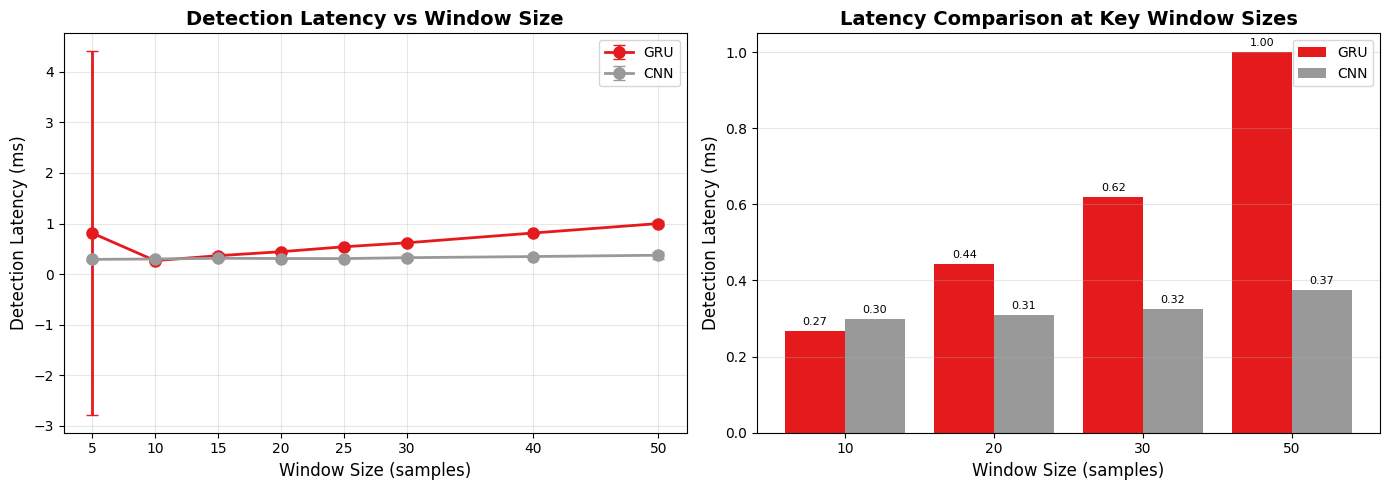

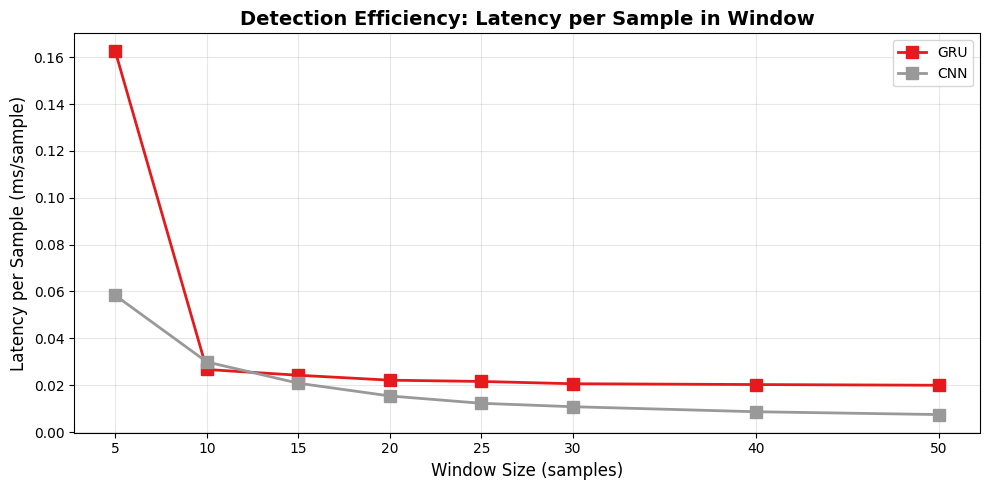

In [40]:
# ======================================================
# Window Size vs Detection Latency Visualization
# ======================================================

if window_latency_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = plt.cm.Set1(np.linspace(0, 1, len(window_latency_results)))
    
    # Plot 1: Line plot with error bars
    ax1 = axes[0]
    for i, (model_name, latencies) in enumerate(window_latency_results.items()):
        if latencies:
            window_sizes = list(latencies.keys())
            avg_times = [latencies[ws]["avg_ms"] for ws in window_sizes]
            std_times = [latencies[ws]["std_ms"] for ws in window_sizes]
            
            ax1.errorbar(window_sizes, avg_times, yerr=std_times, 
                        marker='o', capsize=4, label=model_name.upper(), 
                        color=colors[i], linewidth=2, markersize=8)
    
    ax1.set_xlabel("Window Size (samples)", fontsize=12)
    ax1.set_ylabel("Detection Latency (ms)", fontsize=12)
    ax1.set_title("Detection Latency vs Window Size", fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(WINDOW_SIZES_TO_TEST)
    
    # Plot 2: Bar chart comparison at specific window sizes
    ax2 = axes[1]
    comparison_windows = [10, 20, 30, 50]
    available_windows = [w for w in comparison_windows if any(w in r for r in window_latency_results.values())]
    
    x = np.arange(len(available_windows))
    width = 0.8 / len(window_latency_results)
    
    for i, (model_name, latencies) in enumerate(window_latency_results.items()):
        values = []
        for ws in available_windows:
            if ws in latencies:
                values.append(latencies[ws]["avg_ms"])
            else:
                values.append(0)
        
        bars = ax2.bar(x + i*width - width*(len(window_latency_results)-1)/2, 
                      values, width, label=model_name.upper(), color=colors[i])
        
        # Add value labels
        for bar, val in zip(bars, values):
            if val > 0:
                ax2.annotate(f'{val:.2f}', 
                            xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                            xytext=(0, 3), textcoords="offset points",
                            ha='center', va='bottom', fontsize=8)
    
    ax2.set_xlabel("Window Size (samples)", fontsize=12)
    ax2.set_ylabel("Detection Latency (ms)", fontsize=12)
    ax2.set_title("Latency Comparison at Key Window Sizes", fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(available_windows)
    ax2.legend(fontsize=10)
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Additional plot: Normalized latency (per sample in window)
    fig2, ax3 = plt.subplots(figsize=(10, 5))
    
    for i, (model_name, latencies) in enumerate(window_latency_results.items()):
        if latencies:
            window_sizes = list(latencies.keys())
            # Latency per sample = total latency / window size
            latency_per_sample = [latencies[ws]["avg_ms"] / ws for ws in window_sizes]
            
            ax3.plot(window_sizes, latency_per_sample, marker='s', 
                    label=model_name.upper(), color=colors[i], linewidth=2, markersize=8)
    
    ax3.set_xlabel("Window Size (samples)", fontsize=12)
    ax3.set_ylabel("Latency per Sample (ms/sample)", fontsize=12)
    ax3.set_title("Detection Efficiency: Latency per Sample in Window", fontsize=14, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)
    ax3.set_xticks(WINDOW_SIZES_TO_TEST)
    
    plt.tight_layout()
    plt.show()

In [41]:
# ======================================================
# Final Window Size Latency Summary
# ======================================================

print("\n" + "="*70)
print("WINDOW SIZE DETECTION LATENCY ANALYSIS COMPLETE")
print("="*70)

if window_latency_results:
    print("\nKey Findings:")
    print("-" * 50)
    
    for model_name, latencies in window_latency_results.items():
        if latencies:
            window_sizes = list(latencies.keys())
            avg_times = [latencies[ws]["avg_ms"] for ws in window_sizes]
            
            # Current default window (20)
            if 20 in latencies:
                current_latency = latencies[20]["avg_ms"]
                print(f"\n{model_name.upper()} (Current Window=20):")
                print(f"  Detection Latency: {current_latency:.4f} ms")
                print(f"  Detections per second: {1000/current_latency:.1f}")
            
            # Recommend optimal window
            min_ws = window_sizes[np.argmin(avg_times)]
            max_ws = window_sizes[np.argmax(avg_times)]
            
            print(f"  Fastest window size: {min_ws} ({latencies[min_ws]['avg_ms']:.4f} ms)")
            print(f"  Slowest window size: {max_ws} ({latencies[max_ws]['avg_ms']:.4f} ms)")
    
    print("\n" + "-"*50)
    print("Interpretation:")
    print("- Lower latency = faster attack detection")
    print("- Larger windows provide more context but increase detection time")
    print("- Choose window size based on accuracy vs speed tradeoff")
    print("="*70)


WINDOW SIZE DETECTION LATENCY ANALYSIS COMPLETE

Key Findings:
--------------------------------------------------

GRU (Current Window=20):
  Detection Latency: 0.4430 ms
  Detections per second: 2257.5
  Fastest window size: 10 (0.2671 ms)
  Slowest window size: 50 (0.9991 ms)

CNN (Current Window=20):
  Detection Latency: 0.3084 ms
  Detections per second: 3243.0
  Fastest window size: 5 (0.2916 ms)
  Slowest window size: 50 (0.3738 ms)

--------------------------------------------------
Interpretation:
- Lower latency = faster attack detection
- Larger windows provide more context but increase detection time
- Choose window size based on accuracy vs speed tradeoff
